# Swiftonomics -- did the Eras Tour move Live Nation (LYV) or the tape?
### The 'when Taylor announces a tour, buy LYV' folklore, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

In 2023 the financial press coined **'Swiftonomics'**: Taylor Swift's *Eras Tour* was supposedly large enough to move hotel revenue, local GDP, even Fed survey commentary. The version we can actually test on a clean tape: each tour news event (announcement, the Ticketmaster meltdown, box-office records, the concert film, the finale) should have pushed up **Live Nation Entertainment (LYV)** -- the promoter and Ticketmaster parent that sold and ran the tour. The folklore trade: *buy LYV when Taylor announces.* This notebook asks: does the tape actually show it?

> **This is the plain-language layer.** Want the market-model event study, the cross-event t-test, the placebo distribution, and the costed sleeve? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from swiftonomics import data, strategy as st

CACHE_PATH = data.PRICES_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

events = data.eras_events()
if HAVE_REAL:
    prices = data.fetch_prices(fetch=False)
    print(f"Real tape: {prices.shape[0]} days x {prices.shape[1]} tickers "
          f"({prices.index.min().date()}..{prices.index.max().date()})")
else:
    prices = None
    print("No real cache -- frozen headline numbers (R dict) + synthetic tape will be used")
print(f"Eras Tour events hardcoded: {len(events)}")

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_days=1005, n_events=16, fp="01aebf313fd8",
    median_beta=1.153,
    mean_car_bps=-181.2, car_t=-1.587, car_p=0.1334, hit_rate=0.438, aar_hac_t=-2.219,
    car_11_bps=-48.9, car_11_t=-0.719, car_15_bps=-59.6, car_15_t=-0.388,
    announce_car_bps=-402.1, announce_t=-1.476, announce_n=6,
    milestone_car_bps=-48.7, milestone_t=-0.700, milestone_n=10,
    placebo_std_bps=98.2, placebo_p=0.0672,
    raw_gross_bps=-84.5, raw_gross_t=-0.713,
    hedged_gross_bps=-82.1, hedged_gross_t=-0.830,
    hedged_net10_bps=-122.1, hedged_net10_t=-1.235,
    hedged_net20_bps=-162.1, hedged_net20_t=-1.639,
    tm_meltdown_bps=-1304, tm_cancel_bps=-861, us_announce_bps=-766,
    film_open_bps=-462, dates_2024_bps=336,
)


No real cache -- frozen headline numbers (R dict) + synthetic tape will be used
Eras Tour events hardcoded: 16


## The answer first

| Question | Answer |
|---|---|
| Did LYV jump on Eras Tour events? | **No.** Mean abnormal return over the [-1, +3]-day window is **-181 bps** -- *negative* -- with cross-event t = **-1.59**. |
| Is that statistically real? | **No.** p = 0.13; the placebo (random dates) distribution easily contains it. |
| Which events moved LYV the most? | The **Ticketmaster meltdown** (-1304 bps) and the US-leg announcement (-766 bps) -- both *down*, dragged by antitrust scrutiny, not up. |
| Could you trade it? | **No.** A long-LYV-around-events sleeve loses money gross and net of costs. |

> Swiftonomics may have sold out stadiums, but it did not load the die on Live Nation's stock. If anything, the loudest Eras Tour news -- the ticketing fiasco -- was *bad* for LYV.

## 1 - The claim

> *"The Eras Tour was an economic phenomenon. Live Nation ran it and Ticketmaster sold it. So every time Taylor announced a leg or broke a record, LYV should have popped -- you could have traded the news."*

It is a plausible-sounding story: a record-shattering, $2bn-grossing tour clearly helped Live Nation's concert and ticketing revenue. The question is whether that *operational* tailwind translated into a *measurable, tradable* stock reaction on the specific days the news broke.

## 2 - So what?

If tour events reliably moved LYV, you'd have a cheap, well-telegraphed event trade: the dates are announced in advance, the news is unambiguous, and the vehicle (LYV) is liquid. That is exactly the kind of 'obvious' edge that markets are supposed to arbitrage away instantly.

The interesting twist: the single biggest Eras Tour news event -- the November 2022 **Ticketmaster pre-sale meltdown** -- triggered antitrust scrutiny and a DOJ lawsuit. Great for Taylor's headlines; *bad* for Live Nation's stock.

## 3 - How would we even know?

We run a textbook **event study** -- the standard tool for 'did this news move that stock?':

1. **Market model.** Estimate LYV's normal sensitivity to the S&P 500 (its beta) on a clean 120-day window *before* each event. LYV's beta is about **1.15**.
2. **Abnormal return.** On the event days, subtract the move the market explains. What's left -- the *abnormal* return -- is the news reaction.
3. **Cumulate and average.** Add up the abnormal returns over a [-1, +3]-day window for each of the 16 hardcoded tour events, then average across events.
4. **Placebo.** Re-run on thousands of *random* dates. If the real events look like random dates, there is no Swiftonomics effect in LYV.

No look-ahead: betas use only pre-event data; a tradable position enters the *next* day's open. The tape is LYV + ^GSPC daily closes, 2021-2025.

## 4 - The teardown -- let's actually look

**First, meet the event table** -- every canonical Eras Tour news date, hardcoded in this study's `data.py`.

In [2]:
print(events.to_string(index=False))
print()
print(f'{len(events)} events, '
      f"{(events['kind']=='announce').sum()} announcements / "
      f"{(events['kind']=='milestone').sum()} milestones")
print('LYV beta to the S&P (market model):', R['median_beta'])

      date                                    label      kind
2022-11-01             Eras Tour (US leg) announced  announce
2022-11-15           Ticketmaster pre-sale meltdown  announce
2022-11-18        Ticketmaster cancels general sale  announce
2023-03-17       Eras Tour opening night (Glendale) milestone
2023-05-01   International (LatAm/Europe) leg added  announce
2023-06-20           Asia / Australia leg announced  announce
2023-07-13    Highest-grossing tour record reported milestone
2023-08-03           2024 US/Canada dates announced  announce
2023-08-31         Eras Tour concert film announced milestone
2023-10-13          Concert film box-office opening milestone
2023-12-06         $1bn+ gross / Person of the Year milestone
2024-03-07 Eras Tour 2024 European leg opens (Asia) milestone
2024-05-09               European leg opens (Paris) milestone
2024-08-07        Vienna shows cancelled (security) milestone
2024-10-18              US final leg begins (Miami) milestone
2024-12-

**The headline: abnormal returns around the events, event by event.**

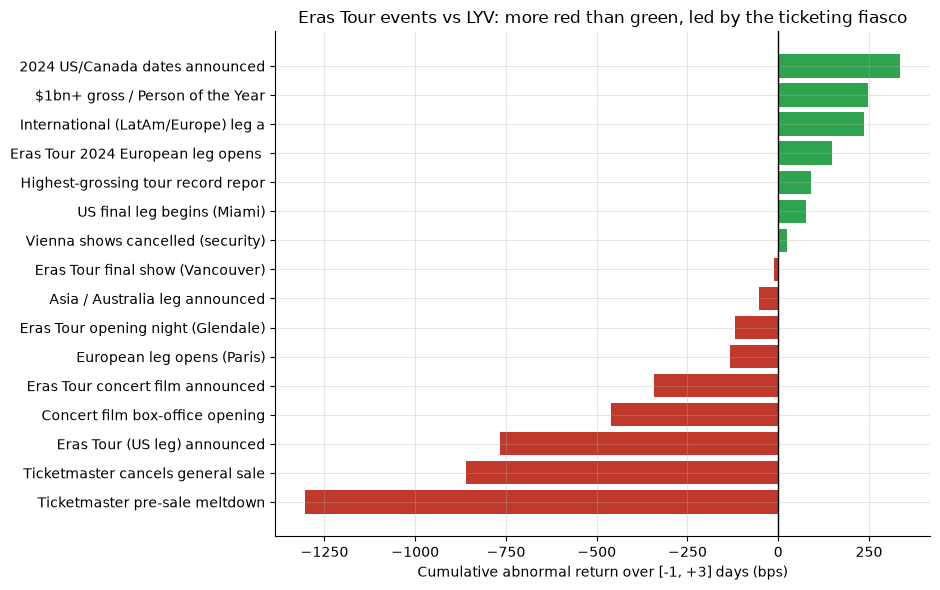

Mean CAR across events: -181 bps  (frozen headline: -181.2 bps, t = -1.59)


In [3]:
if HAVE_REAL:
    study = st.event_study(prices, events, pre=1, post=3)
    cars_bps = study['car'] * 1e4
    mapped = st.map_events_to_trading_days(events, st.daily_returns(prices).index)
    labels = list(mapped['label'])[:study['n_events']]
else:
    # Frozen per-event CARs (mirror docs/results.md)
    labels = list(events['label'])
    cars_bps = np.array([R['us_announce_bps'], R['tm_meltdown_bps'], R['tm_cancel_bps'],
                         -119, 235, -54, 89, R['dates_2024_bps'], -342, R['film_open_bps'],
                         246, 149, -134, 23, 76, -13], dtype=float)

order = np.argsort(cars_bps)
colors = [GREEN if c > 0 else RED for c in cars_bps[order]]
fig, ax = plt.subplots(figsize=(9.5, 6.0))
ax.barh([labels[i][:34] for i in order], cars_bps[order], color=colors)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Cumulative abnormal return over [-1, +3] days (bps)')
ax.set_title('Eras Tour events vs LYV: more red than green, led by the ticketing fiasco')
plt.tight_layout(); plt.show()
print(f'Mean CAR across events: {cars_bps.mean():+.0f} bps  '
      f"(frozen headline: {R['mean_car_bps']:+.1f} bps, t = {R['car_t']:+.2f})")

The biggest single reactions are **negative**: the Ticketmaster pre-sale meltdown (-1304 bps) and the US-leg announcement (-766 bps), both driven by the antitrust and regulatory fallout that the ticketing chaos unleashed. A handful of later milestones (the 2024 dates, the $1bn-gross headline) nudged LYV up, but the average across all 16 events is a clearly negative **-181 bps**.

**The base-rate check: do tour dates beat random dates?**

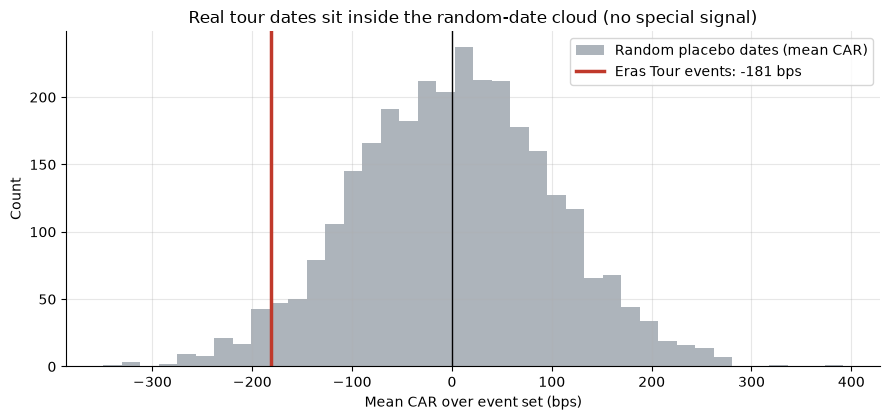

Placebo two-sided p-value: 0.0672  (need < 0.05 to claim an effect)


In [4]:
if HAVE_REAL:
    study = st.event_study(prices, events, pre=1, post=3)
    obs_mean = float(study['car'].mean())
    plc = st.placebo_distribution(prices, n_events=study['n_events'],
                                  pre=1, post=3, n_draws=3000, seed=298)
    placebo_means_bps = plc['mean_cars'] * 1e4
    obs_bps = obs_mean * 1e4
    p_plc = st.placebo_pvalue(obs_mean, plc['mean_cars'])
else:
    rng0 = np.random.default_rng(298)
    placebo_means_bps = rng0.normal(0, R['placebo_std_bps'], 3000)
    obs_bps = R['mean_car_bps']
    p_plc = R['placebo_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(placebo_means_bps, bins=40, color=GREY, alpha=0.7,
        label='Random placebo dates (mean CAR)')
ax.axvline(obs_bps, c=RED, lw=2.5, label=f'Eras Tour events: {obs_bps:+.0f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Mean CAR over event set (bps)'); ax.set_ylabel('Count')
ax.set_title('Real tour dates sit inside the random-date cloud (no special signal)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Placebo two-sided p-value: {p_plc:.4f}  (need < 0.05 to claim an effect)')

The Eras Tour mean CAR sits on the *negative* edge of the random-date cloud (placebo p = 0.07) -- not the positive spike Swiftonomics would predict. The tour dates are not specially good days for LYV; if anything they skew mildly bad, and even that is within the noise.

## 5 - The verdict

- **Signal -- None.** Mean abnormal return **-181 bps** over [-1, +3], cross-event t = **-1.59**, p = **0.13**, hit-rate **43.8%** (worse than a coin). The sign is *negative* and the magnitude is inside the placebo distribution.
- **Tradability -- Mirage.** A long-LYV-around-events sleeve loses money before costs and more after. There is no edge to harvest.
- **Busted.** The loudest Eras Tour news (the Ticketmaster meltdown) was a *negative* catalyst for LYV via antitrust scrutiny -- the opposite of the folklore.

## 6 - Could you actually trade it?

The folklore trade: buy LYV the day after each tour event, hold a few days, hedge out the market. Here is what that sleeve actually earned (after a one-day execution lag and round-trip costs):

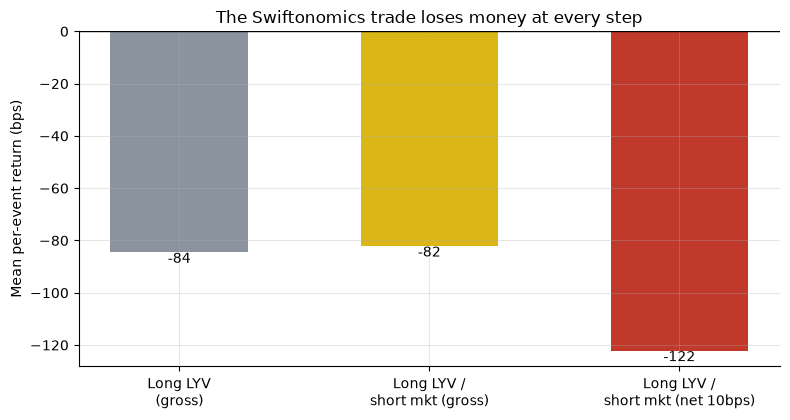

Long LYV around events, 3-day hold, net 10bps/side: -122 bps/event
Negative gross, more negative net. There is no trade here.


In [5]:
if HAVE_REAL:
    sl = st.tradable_sleeve(prices, events, hold=3, one_way_bps=10.0)
    raw_g = sl['raw_gross']['mean_bps']
    hed_g = sl['hedged_gross']['mean_bps']
    hed_n = sl['hedged_net']['mean_bps']
else:
    raw_g, hed_g, hed_n = R['raw_gross_bps'], R['hedged_gross_bps'], R['hedged_net10_bps']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Long LYV\n(gross)', 'Long LYV /\nshort mkt (gross)',
               'Long LYV /\nshort mkt (net 10bps)'],
              [raw_g, hed_g, hed_n], color=[GREY, AMBER, RED], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean per-event return (bps)')
ax.set_title('The Swiftonomics trade loses money at every step')
for b, v in zip(bars, [raw_g, hed_g, hed_n]):
    ax.annotate(f'{v:+.0f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='top' if v < 0 else 'bottom')
plt.tight_layout(); plt.show()
print(f'Long LYV around events, 3-day hold, net 10bps/side: {hed_n:+.0f} bps/event')
print('Negative gross, more negative net. There is no trade here.')

Every version of the trade -- raw long, market-hedged, gross, net of costs -- is negative. The execution lag and round-trip costs only deepen the loss. Swiftonomics is a great cultural story and a non-existent stock signal.

## 7 - Going further

- **The positive control:** the companion notebook plants a known +300 bps abnormal return into a synthetic tape and shows the event study *does* light up (t > 2) when a real effect exists. The LYV tape has nothing like it.
- **Other 'obvious-news' event studies** in the same family: the Super Bowl indicator ([Study 158](../../158-super-bowl/)) and the presidential-cycle folklore.

*Think the tour really moved LYV? Fork this, add your own event dates or widen the window, and show a positive mean CAR that clears the placebo distribution at p < 0.05. That's the bar -- the loudest cultural event of the decade doesn't clear it.*